Echo class imported successfully from /home/gem/wz/心脏/混合/单一.
CAMUS 训练集样本数: 400
CAMUS 验证集样本数: 50
Echo 训练集样本数: 6014
Echo 验证集样本数: 2004
Echo 测试集样本数: 2006
现在训练的训练集样本数: 6414
现在训练的验证集样本数: 2054
现在训练的测试集样本数: 2056
开始训练...
Epoch 1/100, Loss: 0.1324, Dice: 0.6860, IoU: 0.5626, Precision: 0.7606, Recall: 0.6520, Accuracy: 0.7189
Validation Loss: 0.3589, Dice: 0.8579, IoU: 0.7516, Precision: 0.8660, Recall: 0.8500, Accuracy: 0.8415
Best model saved with Dice: 0.8579
Epoch 2/100, Loss: 0.0855, Dice: 0.8728, IoU: 0.7743, Precision: 0.8660, Recall: 0.8799, Accuracy: 0.8586
Validation Loss: 0.3091, Dice: 0.8834, IoU: 0.7913, Precision: 0.8760, Recall: 0.8910, Accuracy: 0.8671
Best model saved with Dice: 0.8834
Epoch 3/100, Loss: 0.0758, Dice: 0.8825, IoU: 0.7898, Precision: 0.8779, Recall: 0.8872, Accuracy: 0.8700
Validation Loss: 0.2873, Dice: 0.8891, IoU: 0.8005, Precision: 0.8839, Recall: 0.8945, Accuracy: 0.8738
Best model saved with Dice: 0.8891
Epoch 4/100, Loss: 0.0699, Dice: 0.8874, IoU: 0.7976,

/tmp/ipykernel_1905307/2889608433.py:415: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


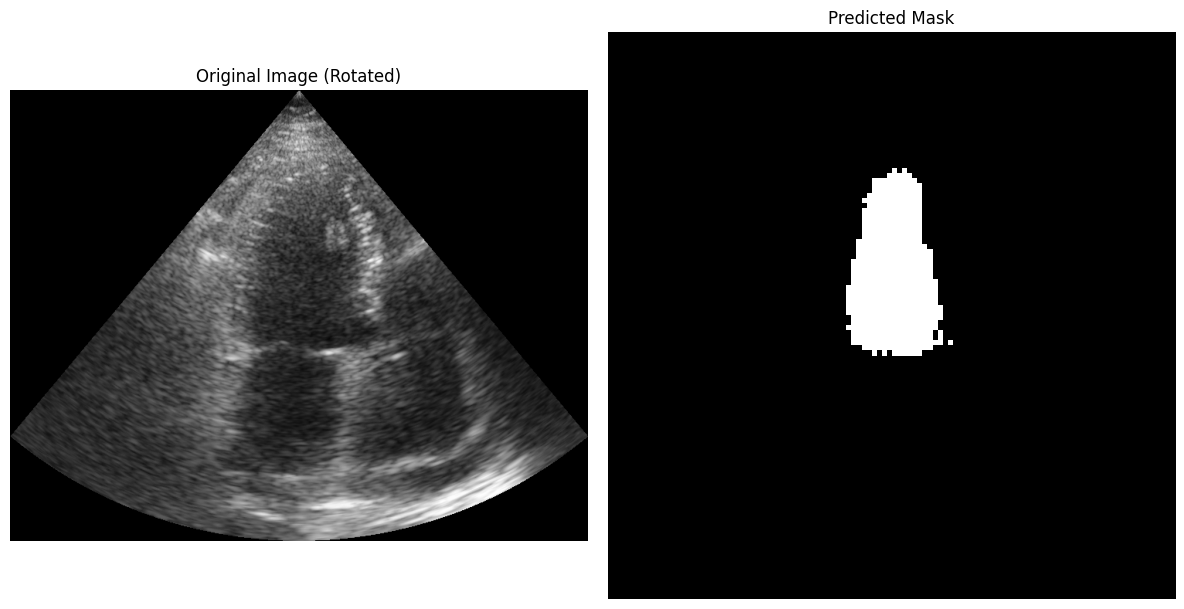

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import SimpleITK as sitk
from torchvision import transforms
import torch.nn.functional as F
from torch import amp
import torchvision.transforms.functional as TF

# 修改路径，确保能找到 echo.py
import sys
sys.path.append('/home/gem/wz/心脏/混合/单一')

# 导入 Echo 类
try:
    from echo import Echo
    print("Echo class imported successfully from /home/gem/wz/心脏/混合/单一.")
except ImportError as e:
    print(f"Error importing Echo: {e}")

# 提升 GPU 性能的设置
torch.backends.cudnn.benchmark = True  # 对于固定输入尺寸非常有用

# 数据预处理
both_transform = transforms.Compose([
    transforms.Resize((112, 112)),  # 将图像尺寸调整为112x112
    transforms.ToTensor(),
])

# 自定义 CAMUS 数据集类
class CAMUS_4CH_Dataset(Dataset):
    def __init__(self, data_dir, split='train'):
        self.data_dir = data_dir
        self.patients_list = sorted([x for x in os.listdir(data_dir) if (os.path.isdir(os.path.join(data_dir, x)) and x.startswith('patient'))])
        if split == 'train':
            self.patients_list = self.patients_list[:400]  # 训练集
        elif split == 'val':
            self.patients_list = self.patients_list[400:450]  # 验证集
        elif split == 'test':
            self.patients_list = self.patients_list[450:]  # 测试集

    def __len__(self):
        return len(self.patients_list)

    def __getitem__(self, index):
        patient_unique_id = str(self.patients_list[index])
        patient_dir = os.path.join(self.data_dir, patient_unique_id)
        image_path = os.path.join(patient_dir, patient_unique_id + "_4CH_ES.nii.gz")
        mask_path = os.path.join(patient_dir, patient_unique_id + "_4CH_ES_gt.nii.gz")

        image_file = sitk.GetArrayFromImage(sitk.ReadImage(image_path, sitk.sitkFloat32))
        mask_file = sitk.GetArrayFromImage(sitk.ReadImage(mask_path, sitk.sitkFloat32))

        mask_file[mask_file != 1] = 0
        mask_file[mask_file == 1] = 1.0

        if image_file.ndim == 2:
            image_file = np.expand_dims(image_file, axis=0)

        if image_file.shape[0] == 1:
            image_file = np.repeat(image_file, 3, axis=0)

        image_file = torch.from_numpy(image_file).float()
        mask_file = torch.from_numpy(np.expand_dims(mask_file, axis=0)).float()

        if image_file.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            image_file = TF.resize(image_file, [112, 112])
        if mask_file.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            mask_file = TF.resize(mask_file, [112, 112])

        image_file = image_file.view(3, 112, 112)  # 调整为112x112
        mask_file = mask_file.view(1, 112, 112)  # 调整为112x112

        return image_file, mask_file

# 自定义 Echo 数据集类
class EchoDataset(Dataset):
    def __init__(self, echo_data):
        self.echo_data = echo_data

    def __len__(self):
        return len(self.echo_data)

    def __getitem__(self, idx):
        image, mask = self.echo_data[idx]

        if isinstance(mask, tuple) and len(mask) == 2:
            large_trace = mask[0]
        else:
            raise ValueError("mask should be a tuple containing two elements.")

        mask_image = (large_trace > 0).astype(np.float32)

        if image.ndim == 4 and image.shape[1] > 1:
            image = image[:, 0, :, :]

        if image.ndim == 3:
            image = np.transpose(image, (2, 0, 1))
        elif image.ndim == 2:
            image = image[np.newaxis, ...]

        if mask_image.ndim == 3:
            mask_image = mask_image[0][np.newaxis, ...]

        image = torch.from_numpy(image).float()
        mask_image = torch.from_numpy(mask_image).float()

        if image.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            image = TF.resize(image, [112, 112])
        if mask_image.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            mask_image = TF.resize(mask_image, [112, 112])

        image = image.view(3, 112, 112)  # 调整为112x112
        mask_image = mask_image.view(1, 112, 112)  # 调整为112x112

        return image, mask_image

# 定义 CombinedDataset 将两个数据集组合
class CombinedDataset(Dataset):
    def __init__(self, camus_dataset, echo_dataset):
        self.camus_dataset = camus_dataset
        self.echo_dataset = echo_dataset
        self.total_len = len(camus_dataset) + len(echo_dataset)
    
    def __len__(self):
        return self.total_len
    
    def __getitem__(self, idx):
        if idx < len(self.camus_dataset):
            return self.camus_dataset[idx]
        else:
            return self.echo_dataset[idx - len(self.camus_dataset)]

# 定义 SegNet 模型
class SegNet(nn.Module):
    def __init__(self):
        super(SegNet, self).__init__()

        # Encoder
        self.encoder = nn.ModuleList([
            self.conv_block(3, 64),
            self.conv_block(64, 128),
            self.conv_block(128, 256),
            self.conv_block(256, 512)
        ])
        
        self.pool = nn.MaxPool2d(2, 2, return_indices=True)
        
        # Decoder
        self.decoder = nn.ModuleList([
            self.deconv_block(512, 256),
            self.deconv_block(256, 128),
            self.deconv_block(128, 64),
            self.deconv_block(64, 64)
        ])
        
        self.unpool = nn.MaxUnpool2d(2, 2)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def deconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        enc_indices = []
        enc_shapes = []

        # Encoder
        for enc in self.encoder:
            x = enc(x)
            enc_shapes.append(x.shape)
            x, indices = self.pool(x)
            enc_indices.append(indices)

        # Decoder
        for i, dec in enumerate(self.decoder):
            x = self.unpool(x, enc_indices[-(i + 1)], output_size=enc_shapes[-(i + 1)])
            x = dec(x)
        
        x = self.final_conv(x)
        return x

# 使用混合精度训练以提高 GPU 效率
scaler = amp.GradScaler()  # 自动混合精度

# 定义分割指标
def calculate_metrics(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > threshold).float()

    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)

    intersection = (y_true_f * y_pred_f).sum()
    dice = (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

    union = y_true_f.sum() + y_pred_f.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)

    tp = (y_true_f * y_pred_f).sum()
    fp = ((1 - y_true_f) * y_pred_f).sum()
    precision = (tp + smooth) / (tp + fp + smooth)

    fn = (y_true_f * (1 - y_pred_f)).sum()
    recall = (tp + smooth) / (tp + fn + smooth)

    tn = ((1 - y_true_f) * (1 - y_pred_f)).sum()
    accuracy = (tp + tn + smooth) / (y_true_f.size(0) + smooth)
    return dice.item(), iou.item(), precision.item(), recall.item(), accuracy.item()

# 验证函数
def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_score = 0.0
    iou_score = 0.0
    precision_score = 0.0
    recall_score = 0.0
    accuracy_score = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                
                dice, iou, precision, recall, accuracy = calculate_metrics(masks, outputs)
                dice_score += dice
                iou_score += iou
                precision_score += precision
                recall_score += recall
                accuracy_score += accuracy

    val_loss /= len(loader)
    metrics = {
        'loss': val_loss,
        'dice': dice_score / len(loader),
        'iou': iou_score / len(loader),
        'precision': precision_score / len(loader),
        'recall': recall_score / len(loader),
        'accuracy': accuracy_score / len(loader),
    }
    return metrics

# 训练函数
def train_model(model, train_loader, val_loader, test_loader, num_epochs=50, learning_rate=0.001, accumulation_steps=4):
    # 指定使用 GPU 3
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 将模型移动到 GPU，使用所有可用的 GPU
    model = nn.DataParallel(model).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    scaler = amp.GradScaler('cuda')
    
    best_dice = 0.0  # 保存最佳Dice得分
    best_model_path = '/home/gem/wz/心脏/混合/权重/best_model_max.pth'

    print("开始训练...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        dice_score = 0.0
        iou_score = 0.0
        precision_score = 0.0
        recall_score = 0.0
        accuracy_score = 0.0
        optimizer.zero_grad()

        for step, (images, masks) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks) / accumulation_steps  # 梯度累积
            
            scaler.scale(loss).backward()
            
            if (step + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            running_loss += loss.item()
            dice, iou, precision, recall, accuracy = calculate_metrics(masks, outputs)
            dice_score += dice
            iou_score += iou
            precision_score += precision
            recall_score += recall
            accuracy_score += accuracy

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Dice: {dice_score/len(train_loader):.4f}, IoU: {iou_score/len(train_loader):.4f}, Precision: {precision_score/len(train_loader):.4f}, Recall: {recall_score/len(train_loader):.4f}, Accuracy: {accuracy_score/len(train_loader):.4f}")
        
        # 验证集评估
        val_metrics = validate(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}, IoU: {val_metrics['iou']:.4f}, Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, Accuracy: {val_metrics['accuracy']:.4f}")
        
        # 保存最佳模型
        if val_metrics['dice'] > best_dice:
            best_dice = val_metrics['dice']
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved with Dice: {best_dice:.4f}")

    # 测试集评估
    print("开始测试...")
    test_metrics = validate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_metrics['loss']:.4f}, IoU: {test_metrics['iou']:.4f}, Dice: {test_metrics['dice']:.4f}, Accuracy: {test_metrics['accuracy']:.4f}, Precision: {test_metrics['precision']:.4f}, Recall: {test_metrics['recall']:.4f}")

# 数据集路径
DATA_DIR_CAMUS = "/home/gem/wz/心脏/CAMUS_public/CAMUS_public/database_nifti"
DATA_DIR_ECHO = "/home/gem/wz/心脏/EchoNet-Dynamic"

# 加载 EchoNet-Dynamic 数据集的完整数据
echo_data_all= Echo(
    root=DATA_DIR_ECHO,
    split="all",  # 加载所有数据
    target_type=["LargeFrame", "LargeTrace"],
    length=1,
    period=1,
    clips=1,
    pad=None,
    noise=None,
    mean=0,
    std=1,
)

# 将 Echo 数据集按照 6:2:2 划分为训练集、验证集和测试集
total_len = len(echo_data_all)
train_len = int(0.6 * total_len)
val_len = int(0.2 * total_len)
test_len = total_len - train_len - val_len

echo_train_data, echo_val_data, echo_test_data = random_split(echo_data_all, [train_len, val_len, test_len])

# 初始化 CAMUS 数据集
camus_train_data = CAMUS_4CH_Dataset(DATA_DIR_CAMUS, split='train')
camus_val_data = CAMUS_4CH_Dataset(DATA_DIR_CAMUS, split='val')
camus_test_data = CAMUS_4CH_Dataset(DATA_DIR_CAMUS, split='test')  # 定义 CAMUS 的测试集

# 包装为 EchoDataset
echo_dataset_train = EchoDataset(echo_train_data)
echo_dataset_val = EchoDataset(echo_val_data)
echo_dataset_test = EchoDataset(echo_test_data)  # 定义 Echo 测试集

combined_dataset_train = CombinedDataset(camus_train_data, echo_dataset_train)
combined_dataset_val = CombinedDataset(camus_val_data, echo_dataset_val)
combined_dataset_test = CombinedDataset(camus_test_data, echo_dataset_test)  # 混合测试集

# 创建 DataLoader
batch_size = 1024  # 保持 batch size 不变
num_workers = 16  # 保持 num_workers 不变
pin_memory = True  # 加速数据从内存到 GPU 的传输

train_loader = DataLoader(combined_dataset_train, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(combined_dataset_val, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(combined_dataset_test, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)  # 使用混合测试集

# 打印 CAMUS 和 Echo 数据集的训练集、验证集和测试集的样本数
print(f"CAMUS 训练集样本数: {len(camus_train_data)}")
print(f"CAMUS 验证集样本数: {len(camus_val_data)}")
print(f"Echo 训练集样本数: {len(echo_dataset_train)}")
print(f"Echo 验证集样本数: {len(echo_dataset_val)}")
print(f"Echo 测试集样本数: {len(echo_dataset_test)}")

# 打印组合后的训练集、验证集和测试集样本数
print(f"现在训练的训练集样本数: {len(train_loader.dataset)}")
print(f"现在训练的验证集样本数: {len(val_loader.dataset)}")
print(f"现在训练的测试集样本数: {len(test_loader.dataset)}")

# 创建模型并训练
model = SegNet()
train_model(model, train_loader, val_loader, test_loader, num_epochs=100)


# ========== 以下为新增的 “模型推理与可视化” 部分 ==========

import nibabel as nib
import matplotlib.pyplot as plt

# 指定训练时保存的最佳模型权重路径（与 train_model 中一致）
best_model_path = '/home/gem/wz/心脏/混合/权重/best_model_max.pth'

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 将模型切换到评估模式，并加载权重
model = SegNet()  # 使用 SegNet 模型
model = nn.DataParallel(model).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 读取用于预测的 NIfTI 图像
image_path = '/home/gem/wz/心脏/CAMUS_public/CAMUS_public/database_nifti/patient0002/patient0002_4CH_ES.nii.gz'

# 使用 nibabel 加载原始图像
image_data = nib.load(image_path).get_fdata()

# 打印一下形状信息（可选）
print("Image Data Shape:", image_data.shape)

# 将图像逆时针旋转 90 度（与给定示例代码的旋转一致）
image_data_rotated = np.rot90(image_data, k=-1)  # k=-1 表示顺时针90度实际效果

# 将旋转后的 2D 图像转换为 3 通道
if image_data_rotated.ndim == 2:
    img = np.expand_dims(image_data_rotated, axis=0)  # shape -> (1, H, W)
else:
    raise ValueError("Expected a 2D image array.")

if img.shape[0] == 1:
    img = np.repeat(img, 3, axis=0)  # shape -> (3, H, W)

# 转为 Torch Tensor 并调整为 float
img_tensor = torch.from_numpy(img).float()

# 如果尺寸不是 112x112，则进行 Resize
if img_tensor.shape[1:] != torch.Size([112, 112]):
    img_tensor = TF.resize(img_tensor, [112, 112])

# 调整形状为 (1, 3, 112, 112) 并移动到设备
img_tensor = img_tensor.view(1, 3, 112, 112).to(device)

# 预测
with torch.no_grad():
    output = model(img_tensor)  # 使用 SegNet 模型进行预测
    pred_mask = torch.sigmoid(output)  # Sigmoid 归一化到 [0,1]
    pred_mask = (pred_mask > 0.5).float()  # 二值化
    pred_mask_np = pred_mask.cpu().numpy()[0, 0, :, :]  # 转为 NumPy 数组, shape -> (112, 112)

# 可视化：原始旋转图像 与 模型预测的 Mask
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 左侧：显示旋转后的原始单帧灰度图
axes[0].imshow(image_data_rotated, cmap='gray')
axes[0].set_title('Original Image (Rotated)')
axes[0].axis('off')

# 右侧：显示模型预测的分割 Mask
axes[1].imshow(pred_mask_np, cmap='gray')
axes[1].set_title('Predicted Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()


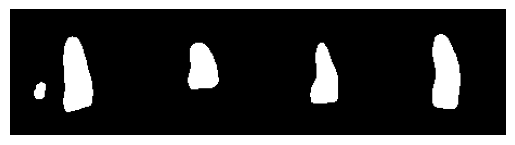

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the mask image
mask_image_path = '/home/gem/wz/222/image_5/prediction.png'
mask = cv2.imread(mask_image_path, cv2.IMREAD_GRAYSCALE)

# Apply a binary threshold to convert to black and white
_, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# Optionally, apply morphological operations to smooth or clean the mask
kernel = np.ones((5, 5), np.uint8)
cleaned_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

# Display the result
plt.imshow(cleaned_mask, cmap='gray')
plt.axis('off')  # Hide axes for better visual presentation
plt.show()


Echo class imported successfully from /home/gem/wz/心脏/混合/单一.
CAMUS 训练集样本数: 400
CAMUS 验证集样本数: 50
Echo 训练集样本数: 6014
Echo 验证集样本数: 2004
Echo 测试集样本数: 2006
现在训练的训练集样本数: 6414
现在训练的验证集样本数: 2054
现在训练的测试集样本数: 2056
开始训练...
Epoch 1/100, Loss: 0.1679, Dice: 0.5722, IoU: 0.4069, Precision: 0.6732, Recall: 0.5857, Accuracy: 0.5628
Validation Loss: 0.6929, Dice: 0.4299, IoU: 0.2738, Precision: 0.5974, Recall: 0.3358, Accuracy: 0.4859
Best model saved with Dice: 0.4299
Epoch 2/100, Loss: 0.1589, Dice: 0.5058, IoU: 0.3401, Precision: 0.8318, Recall: 0.3650, Accuracy: 0.6099
Validation Loss: 0.7046, Dice: 0.0000, IoU: 0.0000, Precision: 1.0000, Recall: 0.0000, Accuracy: 0.4226
Epoch 3/100, Loss: 0.1473, Dice: 0.6225, IoU: 0.4552, Precision: 0.8360, Recall: 0.5035, Accuracy: 0.6708
Validation Loss: 0.6996, Dice: 0.1114, IoU: 0.0593, Precision: 0.9789, Recall: 0.0594, Accuracy: 0.4558
Epoch 4/100, Loss: 0.1353, Dice: 0.7557, IoU: 0.6122, Precision: 0.8098, Recall: 0.7199, Accuracy: 0.7518
Validation Loss: 

/tmp/ipykernel_1206242/3076591750.py:415: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Image Data Shape: (630, 519)


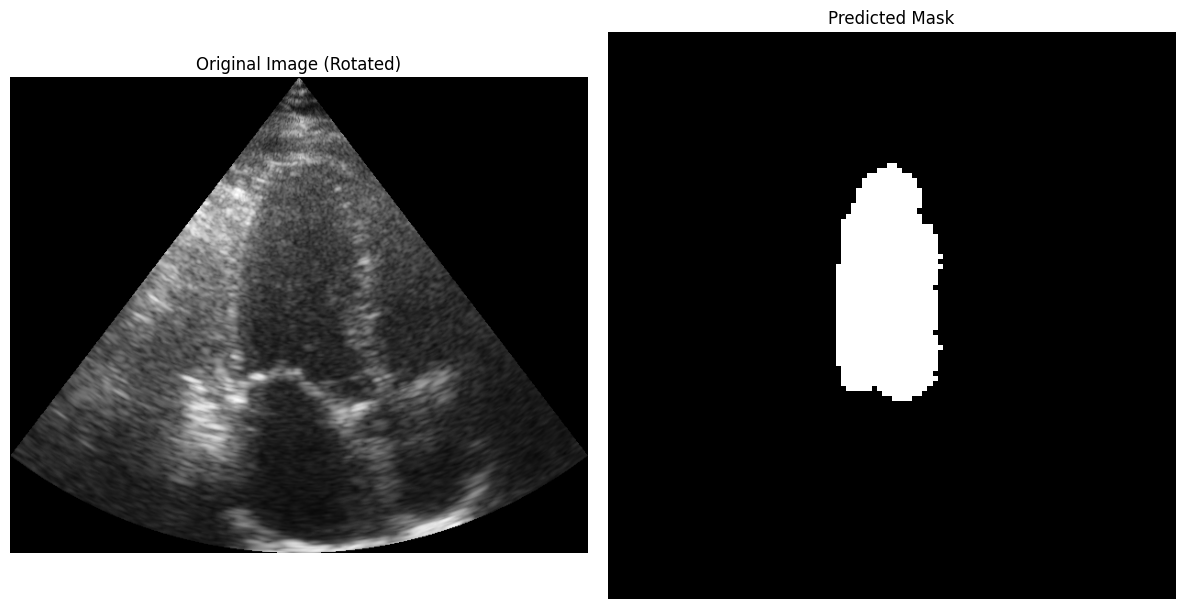

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import SimpleITK as sitk
from torchvision import transforms
import torch.nn.functional as F
from torch import amp
import torchvision.transforms.functional as TF

# 修改路径，确保能找到 echo.py
import sys
sys.path.append('/home/gem/wz/心脏/混合/单一')

# 导入 Echo 类
try:
    from echo import Echo
    print("Echo class imported successfully from /home/gem/wz/心脏/混合/单一.")
except ImportError as e:
    print(f"Error importing Echo: {e}")

# 提升 GPU 性能的设置
torch.backends.cudnn.benchmark = True  # 对于固定输入尺寸非常有用

# 数据预处理
both_transform = transforms.Compose([
    transforms.Resize((112, 112)),  # 将图像尺寸调整为112x112
    transforms.ToTensor(),
])

# 自定义 CAMUS 数据集类
class CAMUS_4CH_Dataset(Dataset):
    def __init__(self, data_dir, split='train'):
        self.data_dir = data_dir
        self.patients_list = sorted([x for x in os.listdir(data_dir) if (os.path.isdir(os.path.join(data_dir, x)) and x.startswith('patient'))])
        if split == 'train':
            self.patients_list = self.patients_list[:400]  # 训练集
        elif split == 'val':
            self.patients_list = self.patients_list[400:450]  # 验证集
        elif split == 'test':
            self.patients_list = self.patients_list[450:]  # 测试集

    def __len__(self):
        return len(self.patients_list)

    def __getitem__(self, index):
        patient_unique_id = str(self.patients_list[index])
        patient_dir = os.path.join(self.data_dir, patient_unique_id)
        image_path = os.path.join(patient_dir, patient_unique_id + "_4CH_ES.nii.gz")
        mask_path = os.path.join(patient_dir, patient_unique_id + "_4CH_ES_gt.nii.gz")

        image_file = sitk.GetArrayFromImage(sitk.ReadImage(image_path, sitk.sitkFloat32))
        mask_file = sitk.GetArrayFromImage(sitk.ReadImage(mask_path, sitk.sitkFloat32))

        mask_file[mask_file != 1] = 0
        mask_file[mask_file == 1] = 1.0

        if image_file.ndim == 2:
            image_file = np.expand_dims(image_file, axis=0)

        if image_file.shape[0] == 1:
            image_file = np.repeat(image_file, 3, axis=0)

        image_file = torch.from_numpy(image_file).float()
        mask_file = torch.from_numpy(np.expand_dims(mask_file, axis=0)).float()

        if image_file.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            image_file = TF.resize(image_file, [112, 112])
        if mask_file.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            mask_file = TF.resize(mask_file, [112, 112])

        image_file = image_file.view(3, 112, 112)  # 调整为112x112
        mask_file = mask_file.view(1, 112, 112)  # 调整为112x112

        return image_file, mask_file

# 自定义 Echo 数据集类
class EchoDataset(Dataset):
    def __init__(self, echo_data):
        self.echo_data = echo_data

    def __len__(self):
        return len(self.echo_data)

    def __getitem__(self, idx):
        image, mask = self.echo_data[idx]

        if isinstance(mask, tuple) and len(mask) == 2:
            large_trace = mask[0]
        else:
            raise ValueError("mask should be a tuple containing two elements.")

        mask_image = (large_trace > 0).astype(np.float32)

        if image.ndim == 4 and image.shape[1] > 1:
            image = image[:, 0, :, :]

        if image.ndim == 3:
            image = np.transpose(image, (2, 0, 1))
        elif image.ndim == 2:
            image = image[np.newaxis, ...]

        if mask_image.ndim == 3:
            mask_image = mask_image[0][np.newaxis, ...]

        image = torch.from_numpy(image).float()
        mask_image = torch.from_numpy(mask_image).float()

        if image.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            image = TF.resize(image, [112, 112])
        if mask_image.shape[1:] != torch.Size([112, 112]):  # 修改为112x112
            mask_image = TF.resize(mask_image, [112, 112])

        image = image.view(3, 112, 112)  # 调整为112x112
        mask_image = mask_image.view(1, 112, 112)  # 调整为112x112

        return image, mask_image

# 定义 CombinedDataset 将两个数据集组合
class CombinedDataset(Dataset):
    def __init__(self, camus_dataset, echo_dataset):
        self.camus_dataset = camus_dataset
        self.echo_dataset = echo_dataset
        self.total_len = len(camus_dataset) + len(echo_dataset)
    
    def __len__(self):
        return self.total_len
    
    def __getitem__(self, idx):
        if idx < len(self.camus_dataset):
            return self.camus_dataset[idx]
        else:
            return self.echo_dataset[idx - len(self.camus_dataset)]

# 定义 SegNet 模型
class SegNet(nn.Module):
    def __init__(self):
        super(SegNet, self).__init__()

        # Encoder
        self.encoder = nn.ModuleList([
            self.conv_block(3, 64),
            self.conv_block(64, 128),
            self.conv_block(128, 256),
            self.conv_block(256, 512)
        ])
        
        self.pool = nn.MaxPool2d(2, 2, return_indices=True)
        
        # Decoder
        self.decoder = nn.ModuleList([
            self.deconv_block(512, 256),
            self.deconv_block(256, 128),
            self.deconv_block(128, 64),
            self.deconv_block(64, 64)
        ])
        
        self.unpool = nn.MaxUnpool2d(2, 2)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def deconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        enc_indices = []
        enc_shapes = []

        # Encoder
        for enc in self.encoder:
            x = enc(x)
            enc_shapes.append(x.shape)
            x, indices = self.pool(x)
            enc_indices.append(indices)

        # Decoder
        for i, dec in enumerate(self.decoder):
            x = self.unpool(x, enc_indices[-(i + 1)], output_size=enc_shapes[-(i + 1)])
            x = dec(x)
        
        x = self.final_conv(x)
        return x

# 使用混合精度训练以提高 GPU 效率
scaler = amp.GradScaler()  # 自动混合精度

# 定义分割指标
def calculate_metrics(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > threshold).float()

    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)

    intersection = (y_true_f * y_pred_f).sum()
    dice = (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

    union = y_true_f.sum() + y_pred_f.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)

    tp = (y_true_f * y_pred_f).sum()
    fp = ((1 - y_true_f) * y_pred_f).sum()
    precision = (tp + smooth) / (tp + fp + smooth)

    fn = (y_true_f * (1 - y_pred_f)).sum()
    recall = (tp + smooth) / (tp + fn + smooth)

    tn = ((1 - y_true_f) * (1 - y_pred_f)).sum()
    accuracy = (tp + tn + smooth) / (y_true_f.size(0) + smooth)
    return dice.item(), iou.item(), precision.item(), recall.item(), accuracy.item()

# 验证函数
def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_score = 0.0
    iou_score = 0.0
    precision_score = 0.0
    recall_score = 0.0
    accuracy_score = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                
                dice, iou, precision, recall, accuracy = calculate_metrics(masks, outputs)
                dice_score += dice
                iou_score += iou
                precision_score += precision
                recall_score += recall
                accuracy_score += accuracy

    val_loss /= len(loader)
    metrics = {
        'loss': val_loss,
        'dice': dice_score / len(loader),
        'iou': iou_score / len(loader),
        'precision': precision_score / len(loader),
        'recall': recall_score / len(loader),
        'accuracy': accuracy_score / len(loader),
    }
    return metrics

# 训练函数
def train_model(model, train_loader, val_loader, test_loader, num_epochs=50, learning_rate=0.001, accumulation_steps=4):
    # 指定使用 GPU 3
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 将模型移动到 GPU，使用所有可用的 GPU
    model = nn.DataParallel(model).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    scaler = amp.GradScaler('cuda')
    
    best_dice = 0.0  # 保存最佳Dice得分
    best_model_path = '/home/gem/wz/心脏/混合/权重/best_model_max.pth'

    print("开始训练...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        dice_score = 0.0
        iou_score = 0.0
        precision_score = 0.0
        recall_score = 0.0
        accuracy_score = 0.0
        optimizer.zero_grad()

        for step, (images, masks) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks) / accumulation_steps  # 梯度累积
            
            scaler.scale(loss).backward()
            
            if (step + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            running_loss += loss.item()
            dice, iou, precision, recall, accuracy = calculate_metrics(masks, outputs)
            dice_score += dice
            iou_score += iou
            precision_score += precision
            recall_score += recall
            accuracy_score += accuracy

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Dice: {dice_score/len(train_loader):.4f}, IoU: {iou_score/len(train_loader):.4f}, Precision: {precision_score/len(train_loader):.4f}, Recall: {recall_score/len(train_loader):.4f}, Accuracy: {accuracy_score/len(train_loader):.4f}")
        
        # 验证集评估
        val_metrics = validate(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}, IoU: {val_metrics['iou']:.4f}, Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, Accuracy: {val_metrics['accuracy']:.4f}")
        
        # 保存最佳模型
        if val_metrics['dice'] > best_dice:
            best_dice = val_metrics['dice']
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved with Dice: {best_dice:.4f}")

    # 测试集评估
    print("开始测试...")
    test_metrics = validate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_metrics['loss']:.4f}, IoU: {test_metrics['iou']:.4f}, Dice: {test_metrics['dice']:.4f}, Accuracy: {test_metrics['accuracy']:.4f}, Precision: {test_metrics['precision']:.4f}, Recall: {test_metrics['recall']:.4f}")

# 数据集路径
DATA_DIR_CAMUS = "/home/gem/wz/心脏/CAMUS_public/CAMUS_public/database_nifti"
DATA_DIR_ECHO = "/home/gem/wz/心脏/EchoNet-Dynamic"

# 加载 EchoNet-Dynamic 数据集的完整数据
echo_data_all= Echo(
    root=DATA_DIR_ECHO,
    split="all",  # 加载所有数据
    target_type=["LargeFrame", "LargeTrace"],
    length=1,
    period=1,
    clips=1,
    pad=None,
    noise=None,
    mean=0,
    std=1,
)

# 将 Echo 数据集按照 6:2:2 划分为训练集、验证集和测试集
total_len = len(echo_data_all)
train_len = int(0.6 * total_len)
val_len = int(0.2 * total_len)
test_len = total_len - train_len - val_len

echo_train_data, echo_val_data, echo_test_data = random_split(echo_data_all, [train_len, val_len, test_len])

# 初始化 CAMUS 数据集
camus_train_data = CAMUS_4CH_Dataset(DATA_DIR_CAMUS, split='train')
camus_val_data = CAMUS_4CH_Dataset(DATA_DIR_CAMUS, split='val')
camus_test_data = CAMUS_4CH_Dataset(DATA_DIR_CAMUS, split='test')  # 定义 CAMUS 的测试集

# 包装为 EchoDataset
echo_dataset_train = EchoDataset(echo_train_data)
echo_dataset_val = EchoDataset(echo_val_data)
echo_dataset_test = EchoDataset(echo_test_data)  # 定义 Echo 测试集

combined_dataset_train = CombinedDataset(camus_train_data, echo_dataset_train)
combined_dataset_val = CombinedDataset(camus_val_data, echo_dataset_val)
combined_dataset_test = CombinedDataset(camus_test_data, echo_dataset_test)  # 混合测试集

# 创建 DataLoader
batch_size = 1024  # 保持 batch size 不变
num_workers = 16  # 保持 num_workers 不变
pin_memory = True  # 加速数据从内存到 GPU 的传输

train_loader = DataLoader(combined_dataset_train, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(combined_dataset_val, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(combined_dataset_test, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)  # 使用混合测试集

# 打印 CAMUS 和 Echo 数据集的训练集、验证集和测试集的样本数
print(f"CAMUS 训练集样本数: {len(camus_train_data)}")
print(f"CAMUS 验证集样本数: {len(camus_val_data)}")
print(f"Echo 训练集样本数: {len(echo_dataset_train)}")
print(f"Echo 验证集样本数: {len(echo_dataset_val)}")
print(f"Echo 测试集样本数: {len(echo_dataset_test)}")

# 打印组合后的训练集、验证集和测试集样本数
print(f"现在训练的训练集样本数: {len(train_loader.dataset)}")
print(f"现在训练的验证集样本数: {len(val_loader.dataset)}")
print(f"现在训练的测试集样本数: {len(test_loader.dataset)}")

# 创建模型并训练
model = SegNet()
train_model(model, train_loader, val_loader, test_loader, num_epochs=100)


# ========== 以下为新增的 “模型推理与可视化” 部分 ==========

import nibabel as nib
import matplotlib.pyplot as plt

# 指定训练时保存的最佳模型权重路径（与 train_model 中一致）
best_model_path = '/home/gem/wz/心脏/混合/权重/best_model_max.pth'

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 将模型切换到评估模式，并加载权重
model = SegNet()  # 使用 SegNet 模型
model = nn.DataParallel(model).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 读取用于预测的 NIfTI 图像
image_path = '/home/gem/wz/心脏/CAMUS_public/CAMUS_public/database_nifti/patient0100/patient0100_4CH_ES.nii.gz'

# 使用 nibabel 加载原始图像
image_data = nib.load(image_path).get_fdata()

# 打印一下形状信息（可选）
print("Image Data Shape:", image_data.shape)

# 将图像逆时针旋转 90 度（与给定示例代码的旋转一致）
image_data_rotated = np.rot90(image_data, k=-1)  # k=-1 表示顺时针90度实际效果

# 将旋转后的 2D 图像转换为 3 通道
if image_data_rotated.ndim == 2:
    img = np.expand_dims(image_data_rotated, axis=0)  # shape -> (1, H, W)
else:
    raise ValueError("Expected a 2D image array.")

if img.shape[0] == 1:
    img = np.repeat(img, 3, axis=0)  # shape -> (3, H, W)

# 转为 Torch Tensor 并调整为 float
img_tensor = torch.from_numpy(img).float()

# 如果尺寸不是 112x112，则进行 Resize
if img_tensor.shape[1:] != torch.Size([112, 112]):
    img_tensor = TF.resize(img_tensor, [112, 112])

# 调整形状为 (1, 3, 112, 112) 并移动到设备
img_tensor = img_tensor.view(1, 3, 112, 112).to(device)

# 预测
with torch.no_grad():
    output = model(img_tensor)  # 使用 SegNet 模型进行预测
    pred_mask = torch.sigmoid(output)  # Sigmoid 归一化到 [0,1]
    pred_mask = (pred_mask > 0.5).float()  # 二值化
    pred_mask_np = pred_mask.cpu().numpy()[0, 0, :, :]  # 转为 NumPy 数组, shape -> (112, 112)

# 可视化：原始旋转图像 与 模型预测的 Mask
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 左侧：显示旋转后的原始单帧灰度图
axes[0].imshow(image_data_rotated, cmap='gray')
axes[0].set_title('Original Image (Rotated)')
axes[0].axis('off')

# 右侧：显示模型预测的分割 Mask
axes[1].imshow(pred_mask_np, cmap='gray')
axes[1].set_title('Predicted Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()
